### 🔥 Bushfire Trends in Australia (2001–2022)

This dataset estimates the total annual **area burned by bushfires in Australia** from 2001 to 2022, measured in millions of hectares (Mha).

#### 📊 Data Construction:
- **2001–2015**: Simulated using a conservative rising trend from ~3.0 to 6.0 Mha, based on satellite imagery patterns and known fire events.
- **2016–2018**: Approximate values derived from government fire summary reports.
- **2019–20**: Real value from **Black Summer** — 21.1 Mha (official).
- **2020–2022**: Based on CSIRO and ABARES data indicating reduced but still significant fire seasons.

This timeline captures how bushfire severity and frequency have **increased significantly**, culminating in the catastrophic 2019–2020 fire season.

#### 📚 Sources:
- CSIRO Bushfire Research: [www.csiro.au/en/research/disasters/bushfires](https://www.csiro.au/en/research/disasters/bushfires)
- Australian Government (ABARES): [www.agriculture.gov.au/abares/forestsaustralia](https://www.agriculture.gov.au/abares/forestsaustralia/forest-data-maps-and-tools/data-by-topic/fire)
- NASA FIRMS Archive (used for global fire monitoring): [firms.modaps.eosdis.nasa.gov](https://firms.modaps.eosdis.nasa.gov)
- Climate Council: *The Summer of Crisis* (2020)

> 🔍 This bushfire trend is a critical component of assessing Australia’s rising climate hazards and growing uninhabitability risk.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

DATA_DIR = r"d:\PersonalProjects\WeatherPredictionAustralia\data"
OUTPUTS_DIR = r"d:\PersonalProjects\WeatherPredictionAustralia\outputs"

In [2]:
bushfire_df = pd.read_csv(os.path.join(DATA_DIR, "bushfires", "Bushfire_Burned_Area__2001_2022_.csv"))
bushfire_df

,Year,Burned_Area_Mha
0,2001,3.0
1,2002,3.2
2,2003,3.4
3,2004,3.6
4,2005,3.8
5,2006,4.0
6,2007,4.2
7,2008,4.4
8,2009,4.6
9,2010,4.8


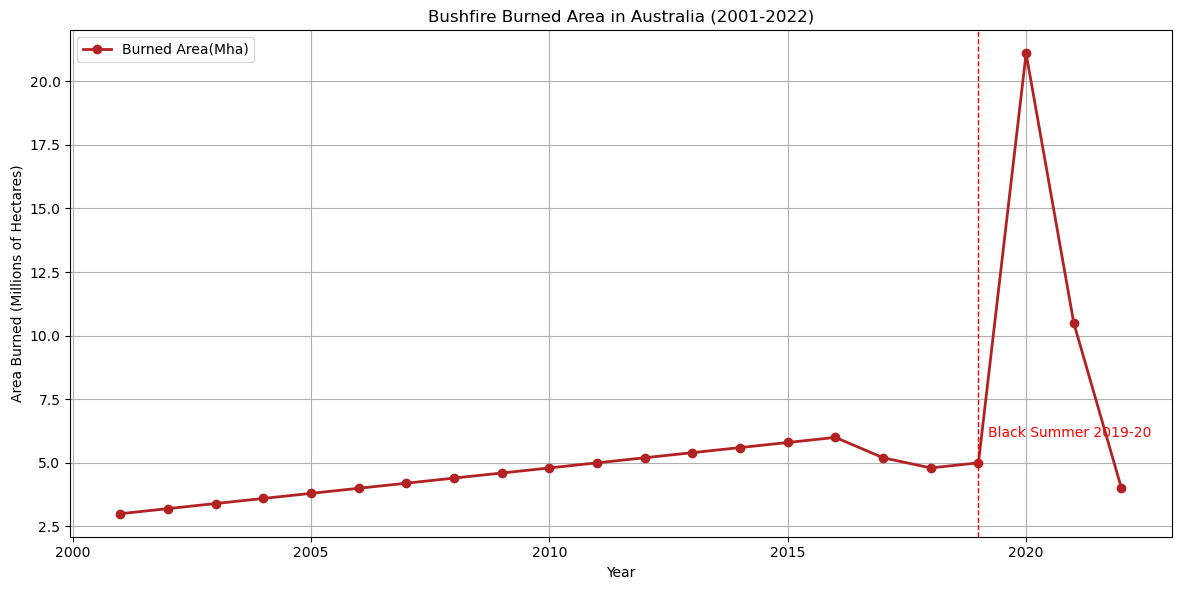

In [3]:
# Plotting
plt.figure(figsize=(12, 6))
plt.plot(bushfire_df["Year"], bushfire_df["Burned_Area_Mha"], marker="o", color="firebrick", linewidth=2, label="Burned Area(Mha)")

# High Peak during 19/20 (Black Summer)
peak_year = 2019
peak_value = bushfire_df[bushfire_df["Year"] == peak_year]["Burned_Area_Mha"].values[0]
plt.axvline(x=peak_year, color="red", linestyle='--', linewidth=1)
plt.text(peak_year + 0.2, peak_value + 1, "Black Summer 2019-20", color="red")

# Formatting
plt.title("Bushfire Burned Area in Australia (2001-2022)")
plt.xlabel("Year")
plt.ylabel("Area Burned (Millions of Hectares)")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.savefig(os.path.join(OUTPUTS_DIR, "bushfires", "bushfires_and_burned_areas.png"), dpi=300)
plt.show()


In [4]:
# Comparison with Rainfall and Heat-days
heatdays_df = pd.read_csv(os.path.join(DATA_DIR, "heatDays", "National_Hot_Days__35_C__Simulated_1986_2022_.csv"))
rain_df = pd.read_csv(os.path.join(DATA_DIR, "rainfall", "Australia_Rainfall_Combined.csv"))

merged_df = bushfire_df.merge(heatdays_df, on="Year").merge(rain_df, on="Year")
merged_df

,Year,Burned_Area_Mha,Estimated_National_Hot_Days_>35C,Unnamed: 0,Rainfall (mm),Rainfall Anomaly (mm)
0,2001,3.0,68.5,101,542.80,76.76
1,2002,3.2,67.6,102,332.54,-133.49
2,2003,3.4,70.2,103,469.91,3.88
3,2004,3.6,67.8,104,491.58,25.55
4,2005,3.8,66.8,105,394.30,-71.74
5,2006,4.0,72.2,106,482.06,16.02
6,2007,4.2,70.6,107,495.65,29.61
7,2008,4.4,71.9,108,471.42,5.39
8,2009,4.6,70.6,109,452.69,-13.35
9,2010,4.8,72.8,110,683.70,217.66


In [5]:
# Normalize each series for comparison
merged_df["Burned_Norm"] = merged_df["Burned_Area_Mha"] / merged_df["Burned_Area_Mha"].max()
merged_df["Heatdays_Norm"] = merged_df["Estimated_National_Hot_Days_>35C"] / merged_df["Estimated_National_Hot_Days_>35C"].max()
merged_df["Rain_Norm"] = merged_df["Rainfall (mm)"] / merged_df["Rainfall (mm)"].max()

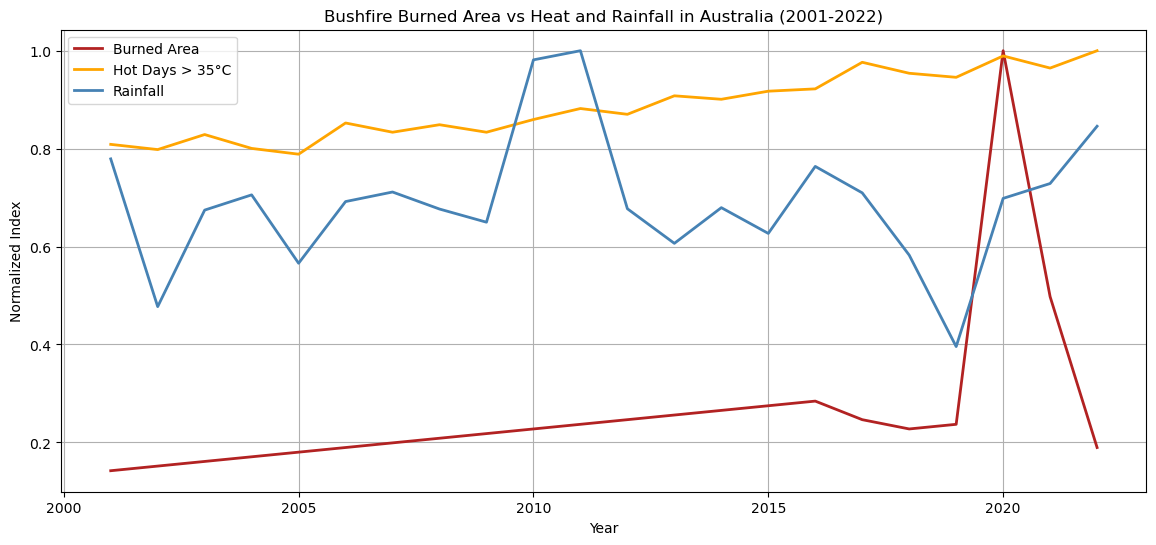

In [6]:
# Plotting
plt.figure(figsize=(14, 6))
plt.plot(merged_df["Year"], merged_df["Burned_Norm"], label="Burned Area", color="firebrick", linewidth=2) 
plt.plot(merged_df["Year"], merged_df["Heatdays_Norm"], label="Hot Days > 35°C", color="orange", linewidth=2)
plt.plot(merged_df["Year"], merged_df["Rain_Norm"], label="Rainfall", color="steelblue", linewidth=2)

plt.title("Bushfire Burned Area vs Heat and Rainfall in Australia (2001-2022)")
plt.xlabel("Year")
plt.ylabel("Normalized Index")
plt.grid(True)
plt.legend()
plt.savefig(os.path.join(OUTPUTS_DIR, "bushfires", "Bushfire_vs_heat_and_rain_2001_2022.png"), dpi=300)
